# Urban Heat Mitigation System

## 1. Data Preprocessing

In [4]:
import numpy
import sklearn
print(numpy.__version__)
print(sklearn.__version__)


1.26.4
1.3.2


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime

In [6]:
zones = {
    "Charminar": (17.3616, 78.4747),
    "Falaknuma": (17.3326, 78.4751),
    "Saidabad": (17.3615, 78.5118),
    "Malakpet": (17.3736, 78.4996),
    "Dilsukhnagar": (17.3684, 78.5228),
    "LB Nagar": (17.3501, 78.5510),
    "Uppal": (17.4025, 78.5612),
    "Habsiguda": (17.4154, 78.5426),
    "Secunderabad": (17.5042, 78.5426),
    "Malkajgiri": (17.4511, 78.5369),
    "Kukatpally": (17.4930, 78.4054),
    "Moosapet": (17.4685, 78.4206),
    "Miyapur": (17.4981, 78.3567),
    "BHEL": (17.4951, 78.2958),
    "Gachibowli": (17.4436, 78.3519),
    "Kondapur": (17.4587, 78.3730),
    "Madhapur": (17.4408, 78.3916),
    "HITEC City": (17.4490, 78.3831),
    "Jubilee Hills": (17.4308, 78.4102),
    "Banjara Hills": (17.4177, 78.4399)
}

def fetch_historical_data(lat, lon):

    url = (
        f"https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={lat}&longitude={lon}"
        f"&start_date=2023-01-01&end_date=2023-12-31"
        f"&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m"
        f"&timezone=auto"
    )

    response = requests.get(url)
    data = response.json()

    df = pd.DataFrame({
        "datetime": data["hourly"]["time"],
        "temperature": data["hourly"]["temperature_2m"],
        "humidity_pct": data["hourly"]["relative_humidity_2m"],
        "wind_speed_kmph": data["hourly"]["wind_speed_10m"]
    })

    return df

all_data = []

for zone, (lat, lon) in zones.items():
    print(f"Fetching data for {zone}")
    df_zone = fetch_historical_data(lat, lon)
    df_zone["zone"] = zone
    all_data.append(df_zone)

df = pd.concat(all_data)

df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour

df.head()


Fetching data for Charminar
Fetching data for Falaknuma
Fetching data for Saidabad
Fetching data for Malakpet
Fetching data for Dilsukhnagar
Fetching data for LB Nagar
Fetching data for Uppal
Fetching data for Habsiguda
Fetching data for Secunderabad
Fetching data for Malkajgiri
Fetching data for Kukatpally
Fetching data for Moosapet
Fetching data for Miyapur
Fetching data for BHEL
Fetching data for Gachibowli
Fetching data for Kondapur
Fetching data for Madhapur
Fetching data for HITEC City
Fetching data for Jubilee Hills
Fetching data for Banjara Hills


,datetime,temperature,humidity_pct,wind_speed_kmph,zone,month,hour
0,2023-01-01 00:00:00,22.5,56,5.8,Charminar,1,0
1,2023-01-01 01:00:00,20.9,63,9.1,Charminar,1,1
2,2023-01-01 02:00:00,20.2,66,8.9,Charminar,1,2
3,2023-01-01 03:00:00,20.6,64,7.2,Charminar,1,3
4,2023-01-01 04:00:00,21.0,63,5.1,Charminar,1,4


In [7]:
#checking missing values
df.isnull().sum()

,0
datetime,0
temperature,0
humidity_pct,0
wind_speed_kmph,0
zone,0
month,0
hour,0


In [8]:
print(df["temperature"].describe())

count    175200.000000
mean         25.659295
std           4.642645
min          10.200000
25%          22.800000
50%          25.300000
75%          28.800000
max          38.800000
Name: temperature, dtype: float64


## 2. Heatspot Identification

In [9]:
#aggregrating columns
avg_zone = df.groupby('zone')['temperature'].mean().reset_index()
avg_zone.head()

,zone,temperature
0,BHEL,25.500126
1,Banjara Hills,25.654635
2,Charminar,25.780719
3,Dilsukhnagar,25.874064
4,Falaknuma,25.780719


In [10]:
#Identifying the hotspots using threshold based rules
Hotspot_Threshold = avg_zone['temperature'].quantile(0.75)

avg_zone['hotspot_label'] = np.where(avg_zone['temperature'] > Hotspot_Threshold,
                                     'Major Hotspot',
                                     'Normal')

avg_zone.sort_values('temperature', ascending= False)
avg_zone

,zone,temperature,hotspot_label
0,BHEL,25.500126,Normal
1,Banjara Hills,25.654635,Normal
2,Charminar,25.780719,Normal
3,Dilsukhnagar,25.874064,Major Hotspot
4,Falaknuma,25.780719,Normal
5,Gachibowli,25.473493,Normal
6,HITEC City,25.473493,Normal
7,Habsiguda,25.874064,Major Hotspot
8,Jubilee Hills,25.568801,Normal
9,Kondapur,25.473493,Normal


In [11]:
major_hotspot = avg_zone[avg_zone['hotspot_label'] == 'Major Hotspot']

print("Major Urban Heat Hotspot:")
for index, row in major_hotspot.iterrows():
    print(f"Zone: {row['zone']}, Average Temperature: {round(row['temperature'],2)} °C")

Major Urban Heat Hotspot:
Zone: Dilsukhnagar, Average Temperature: 25.87 °C
Zone: Habsiguda, Average Temperature: 25.87 °C
Zone: LB Nagar, Average Temperature: 25.97 °C
Zone: Saidabad, Average Temperature: 25.87 °C
Zone: Uppal, Average Temperature: 25.87 °C


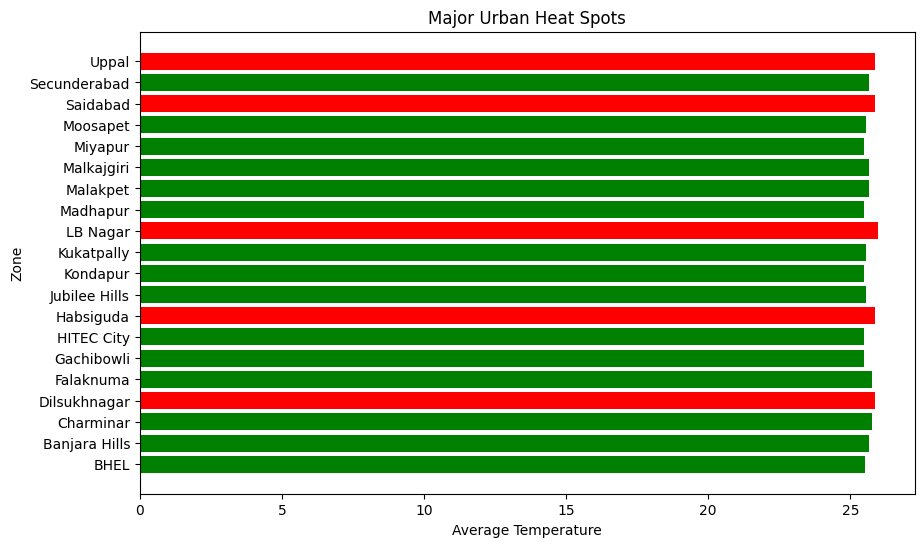

In [12]:
# Visualizing the hotspots
colors = ['red' if label == 'Major Hotspot' else 'green' for label in avg_zone['hotspot_label']]
plt.figure(figsize=(10,6))
plt.barh(avg_zone['zone'], avg_zone['temperature'], color = colors)
plt.title('Major Urban Heat Spots')
plt.xlabel('Average Temperature')
plt.ylabel('Zone')
plt.show()

In [13]:
print("Total Major Hotspots:", len(major_hotspot))

Total Major Hotspots: 5


In [14]:
!pip install folium geopy

In [15]:
zone_coordinates = {
    "Charminar": (17.3616, 78.4747),
    "Falaknuma": (17.3326, 78.4751),
    "Saidabad": (17.3615, 78.5118),
    "Malakpet": (17.3736, 78.4996),
    "Dilsukhnagar": (17.3684, 78.5228),
    "LB Nagar": (17.3501, 78.5510),
    "Uppal": (17.4025, 78.5612),
    "Habsiguda": (17.4154, 78.5426),
    "Secunderabad": (17.5042, 78.5426),
    "Malkajgiri": (17.4511, 78.5369),
    "Kukatpally": (17.4930, 78.4054),
    "Moosapet": (17.4685, 78.4206),
    "Miyapur": (17.4981, 78.3567),
    "BHEL": (17.4951, 78.2958),
    "Gachibowli": (17.4436, 78.3519),
    "Kondapur": (17.4587, 78.3730),
    "Madhapur": (17.4408, 78.3916),
    "HITEC City": (17.4490, 78.3831),
    "Jubilee Hills": (17.4308, 78.4102),
    "Banjara Hills": (17.4177, 78.4399)
}

df["latitude"] = df["zone"].map(lambda x: zone_coordinates[x][0])
df["longitude"] =df["zone"].map(lambda x: zone_coordinates[x][1])

In [16]:
df

,datetime,temperature,humidity_pct,wind_speed_kmph,zone,month,hour,latitude,longitude
0,2023-01-01 00:00:00,22.5,56,5.8,Charminar,1,0,17.3616,78.4747
1,2023-01-01 01:00:00,20.9,63,9.1,Charminar,1,1,17.3616,78.4747
2,2023-01-01 02:00:00,20.2,66,8.9,Charminar,1,2,17.3616,78.4747
3,2023-01-01 03:00:00,20.6,64,7.2,Charminar,1,3,17.3616,78.4747
4,2023-01-01 04:00:00,21.0,63,5.1,Charminar,1,4,17.3616,78.4747
...,...,...,...,...,...,...,...,...,...
8755,2023-12-31 19:00:00,20.9,66,8.4,Banjara Hills,12,19,17.4177,78.4399
8756,2023-12-31 20:00:00,19.6,74,7.3,Banjara Hills,12,20,17.4177,78.4399
8757,2023-12-31 21:00:00,18.5,81,7.2,Banjara Hills,12,21,17.4177,78.4399
8758,2023-12-31 22:00:00,17.5,88,8.9,Banjara Hills,12,22,17.4177,78.4399


In [17]:
import folium
from folium.plugins import HeatMap

# Average temperature per zone
zone_avg = df.groupby("zone").agg({
    "latitude": "first",
    "longitude": "first",
    "temperature": "mean"
}).reset_index()

# Normalize temperature (important for stronger visual contrast)
max_temp = zone_avg["temperature"].max()
min_temp = zone_avg["temperature"].min()

zone_avg["normalized_temp"] = (
    (zone_avg["temperature"] - min_temp) /
    (max_temp - min_temp)
)

# Base map
hyderabad_map = folium.Map(
    location=[17.3850, 78.4867],
    zoom_start=11
)

# Heat data
heat_data = zone_avg[["latitude", "longitude", "normalized_temp"]].values.tolist()

# Custom gradient (darker center)
gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    0.8: 'orange',
    1.0: 'red'
}

# Add heatmap with larger radius & less blur
HeatMap(
    heat_data,
    radius=45,     # Increased size
    blur=15,       # Lower blur → darker center
    max_zoom=13,
    gradient=gradient
).add_to(hyderabad_map)

for _, row in zone_avg.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=f"{row['zone']}<br>Avg Temp: {round(row['temperature'],1)} °C"
    ).add_to(hyderabad_map)


# Save map
hyderabad_map.save("hyderabad_heatmap.html")

print("Heatmap saved as hyderabad_heatmap.html")

Heatmap saved as hyderabad_heatmap.html


## 3. Heatwave Alert Detection

In [18]:
#statistically detecting the heatwave
heatwave_threshold = avg_zone['temperature'].quantile(0.90)

print('Heatwave Alert Threshold:', round(heatwave_threshold,2),"°C")

Heatwave Alert Threshold: 25.87 °C


In [19]:
df['heatwave_alert'] = df['temperature'] > heatwave_threshold

#heatwave counts per zone
heatwave_counts = df.groupby('zone')['heatwave_alert'].sum().reset_index()
heatwave_counts = heatwave_counts.sort_values('heatwave_alert', ascending=False)

heatwave_counts.head()

,zone,heatwave_alert
11,LB Nagar,4244
19,Uppal,4157
3,Dilsukhnagar,4157
17,Saidabad,4157
7,Habsiguda,4157


In [20]:
df

,datetime,temperature,humidity_pct,wind_speed_kmph,zone,month,hour,latitude,longitude,heatwave_alert
0,2023-01-01 00:00:00,22.5,56,5.8,Charminar,1,0,17.3616,78.4747,False
1,2023-01-01 01:00:00,20.9,63,9.1,Charminar,1,1,17.3616,78.4747,False
2,2023-01-01 02:00:00,20.2,66,8.9,Charminar,1,2,17.3616,78.4747,False
3,2023-01-01 03:00:00,20.6,64,7.2,Charminar,1,3,17.3616,78.4747,False
4,2023-01-01 04:00:00,21.0,63,5.1,Charminar,1,4,17.3616,78.4747,False
...,...,...,...,...,...,...,...,...,...,...
8755,2023-12-31 19:00:00,20.9,66,8.4,Banjara Hills,12,19,17.4177,78.4399,False
8756,2023-12-31 20:00:00,19.6,74,7.3,Banjara Hills,12,20,17.4177,78.4399,False
8757,2023-12-31 21:00:00,18.5,81,7.2,Banjara Hills,12,21,17.4177,78.4399,False
8758,2023-12-31 22:00:00,17.5,88,8.9,Banjara Hills,12,22,17.4177,78.4399,False


These zones experienced the highest number of heatwave-alert days during the study period.

## 4. Heatwave Impact Prediction

In [ ]:
pip install xgboost

: 

In [ ]:
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

In [21]:
X =df[["humidity_pct", "wind_speed_kmph", "month", "hour"]]
y = df['temperature']

In [22]:
target = 'temperature'

In [23]:
X

,humidity_pct,wind_speed_kmph,month,hour
0,56,5.8,1,0
1,63,9.1,1,1
2,66,8.9,1,2
3,64,7.2,1,3
4,63,5.1,1,4
...,...,...,...,...
8755,66,8.4,12,19
8756,74,7.3,12,20
8757,81,7.2,12,21
8758,88,8.9,12,22


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

#preprocessing using pipelines
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 5. Hotspot Classification

In [32]:
summer_df = df[df["month"].isin([4, 5, 6])]

In [33]:
# Normalize important columns first
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = ["temperature", "humidity_pct", "wind_speed_kmph"]

summer_df[cols_to_scale] = scaler.fit_transform(summer_df[cols_to_scale])

# Compute vulnerability score
summer_df["heat_vulnerability_score"] = (
    0.5 * summer_df["temperature"] +
    0.3 * summer_df["humidity_pct"] -
    0.2 * summer_df["wind_speed_kmph"]
)


/tmp/ipython-input-2799430632.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_df[cols_to_scale] = scaler.fit_transform(summer_df[cols_to_scale])
/tmp/ipython-input-2799430632.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_df["heat_vulnerability_score"] = (


In [34]:
zone_summary = summer_df.groupby("zone").agg({
    "temperature": "max",              # Peak heat
    "humidity_pct": "mean",
    "wind_speed_kmph": "mean",
    "heat_vulnerability_score": "mean"
}).reset_index()

In [35]:
q75 = zone_summary["heat_vulnerability_score"].quantile(0.75)
q50 = zone_summary["heat_vulnerability_score"].quantile(0.50)
q25 = zone_summary["heat_vulnerability_score"].quantile(0.25)

def classify_hotspot(row):

    score = row["heat_vulnerability_score"]

    if score >= q75:
        return "Extreme Hotspot"
    elif score >= q50:
        return "High Hotspot"
    elif score >= q25:
        return "Moderate Risk"
    else:
        return "Low Risk"

zone_summary["hotspot_category"] = zone_summary.apply(classify_hotspot, axis=1)

## 5. Mitigation Stratagies

In [36]:
def recommend_solutions(row):

    solutions = []

    # 🔴 Extreme Hotspot
    if row["hotspot_category"] == "Extreme Hotspot":
        solutions.extend([
            "Cool Roof Program",
            "Reflective Pavements",
            "Urban Ventilation Corridors",
            "Emergency Cooling Centers"
        ])

    # 🟠 High Hotspot
    elif row["hotspot_category"] == "High Hotspot":
        solutions.extend([
            "Urban Micro Parks",
            "Tree Plantation Drives",
            "Rooftop Solar Integration"
        ])

    # 🟡 Moderate Risk
    elif row["hotspot_category"] == "Moderate Risk":
        solutions.extend([
            "Community Tree Drives",
            "Rainwater Harvesting",
            "Albedo Paint Improvements"
        ])

    # 🟢 Low Risk
    else:
        solutions.extend([
            "Preserve Green Zones",
            "Biodiversity Protection"
        ])

    # 🌡 High Humidity + Heat Stress
    if row["humidity_pct"] > 0.7:  # scaled value
        solutions.append("Public Cooling Shelters")

    # 🌬 Low Wind → Heat Stagnation
    if row["wind_speed_kmph"] < 0.3:  # scaled value
        solutions.append("Wind Corridor Planning")

    return list(set(solutions))


In [37]:
zone_summary["recommended_solutions"] = zone_summary.apply(
    recommend_solutions,
    axis=1
)

zone_summary = zone_summary.sort_values(
    "heat_vulnerability_score",
    ascending=False
)

zone_summary[[
    "zone",
    "hotspot_category",
    "heat_vulnerability_score",
    "recommended_solutions",
    "temperature"
]]

,zone,hotspot_category,heat_vulnerability_score,recommended_solutions,temperature
19,Uppal,Extreme Hotspot,0.309001,"[Emergency Cooling Centers, Reflective Pavemen...",1.000000
3,Dilsukhnagar,Extreme Hotspot,0.309001,"[Emergency Cooling Centers, Reflective Pavemen...",1.000000
17,Saidabad,Extreme Hotspot,0.309001,"[Emergency Cooling Centers, Reflective Pavemen...",1.000000
7,Habsiguda,Extreme Hotspot,0.309001,"[Emergency Cooling Centers, Reflective Pavemen...",1.000000
13,Malakpet,Extreme Hotspot,0.308086,"[Emergency Cooling Centers, Reflective Pavemen...",0.984043
1,Banjara Hills,Extreme Hotspot,0.308086,"[Emergency Cooling Centers, Reflective Pavemen...",0.984043
11,LB Nagar,High Hotspot,0.306246,"[Urban Micro Parks, Tree Plantation Drives, Ro...",1.000000
8,Jubilee Hills,High Hotspot,0.305893,"[Urban Micro Parks, Tree Plantation Drives, Ro...",0.973404
2,Charminar,High Hotspot,0.305193,"[Urban Micro Parks, Tree Plantation Drives, Ro...",0.989362
4,Falaknuma,High Hotspot,0.305193,"[Urban Micro Parks, Tree Plantation Drives, Ro...",0.989362


In [38]:
for _, row in zone_summary.iterrows():
    print("Zone:", row["zone"])
    print("Category:", row["hotspot_category"])
    print("Vulnerability Score:", round(row["heat_vulnerability_score"], 2))
    print("Recommended Actions:")
    for action in row["recommended_solutions"]:
        print("  -", action)
    print("-" * 50)

Zone: Uppal
Category: Extreme Hotspot
Vulnerability Score: 0.31
Recommended Actions:
  - Emergency Cooling Centers
  - Reflective Pavements
  - Cool Roof Program
  - Urban Ventilation Corridors
--------------------------------------------------
Zone: Dilsukhnagar
Category: Extreme Hotspot
Vulnerability Score: 0.31
Recommended Actions:
  - Emergency Cooling Centers
  - Reflective Pavements
  - Cool Roof Program
  - Urban Ventilation Corridors
--------------------------------------------------
Zone: Saidabad
Category: Extreme Hotspot
Vulnerability Score: 0.31
Recommended Actions:
  - Emergency Cooling Centers
  - Reflective Pavements
  - Cool Roof Program
  - Urban Ventilation Corridors
--------------------------------------------------
Zone: Habsiguda
Category: Extreme Hotspot
Vulnerability Score: 0.31
Recommended Actions:
  - Emergency Cooling Centers
  - Reflective Pavements
  - Cool Roof Program
  - Urban Ventilation Corridors
--------------------------------------------------
Zone: 

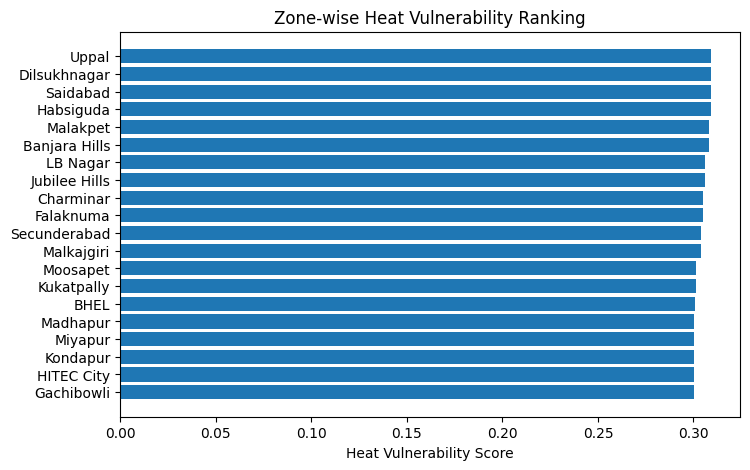

In [39]:
plt.figure(figsize=(8,5))
plt.barh(zone_summary["zone"],
         zone_summary["heat_vulnerability_score"])
plt.xlabel("Heat Vulnerability Score")
plt.title("Zone-wise Heat Vulnerability Ranking")
plt.gca().invert_yaxis()
plt.show()

In [40]:
import joblib

joblib.dump(rf_pipeline, "weather_model_updated.pkl")

['weather_model_updated.pkl']

In [41]:
from google.colab import files
files.download("weather_model_updated.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>